---
# Data Cleaning & Preliminary Analysis

# **EMIF Group Project 1**
#### Aymen Laraoui, Rijad Talovic, Alexis Gavillet, Clémence Choukroun

## Data Cleaning : Weekly Frequency

Selected Variables
- **WTI** : WTI crude oil futures (CL1 Comdty)
- **HY** : Bloomberg US Corporate High Yield Index (LF98YW Index)
- **SP500** : S&P 500 Index (SPX Index)
- **US2Y** : US Government 2-Year Yield (USGG2YR Index)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

## 1. Data Loading

In [2]:
raw_path = Path("../data/raw/data_hec_projet_1.xlsx")
daily_raw = pd.read_excel(raw_path, sheet_name="Daily", skiprows=5, index_col=0, parse_dates=True)

print("Raw dimensions:", daily_raw.shape)
daily_raw.head()

Raw dimensions: (9443, 13)


,PX_LAST,PX_LAST.1,PX_LAST.2,PX_LAST.3,PX_LAST.4,PX_LAST.5,PX_LAST.6,PX_LAST.7,PX_LAST.8,PX_LAST.9,PX_LAST.10,PX_LAST.11,PX_LAST.12
Dates,,,,,,,,,,,,,
1990-01-01,21.82,19.69,77.8405,NaN,NaN,353.40,567.34,214.69,168.228,7.935,7.841,16.08,401.25
1990-01-02,22.89,19.90,81.0621,NaN,NaN,359.69,568.96,217.30,169.943,7.930,7.875,16.08,399.00
1990-01-03,23.68,20.95,83.0504,NaN,NaN,358.76,569.10,220.45,170.780,7.974,7.927,16.08,395.00
1990-01-04,23.41,20.78,81.1315,NaN,NaN,355.67,571.02,227.30,170.168,7.972,7.910,16.08,396.50
1990-01-05,23.08,20.75,78.7509,NaN,NaN,352.20,566.36,228.91,169.713,7.984,7.885,16.08,405.00


In [3]:
#filtering for selected variables
df = daily_raw.iloc[:, [0, 5, 10, 11]].copy()
df.columns = ["WTI", "SP500", "US2Y", "HY"]

df.head()

,WTI,SP500,US2Y,HY
Dates,,,,
1990-01-01,21.82,353.40,7.841,16.08
1990-01-02,22.89,359.69,7.875,16.08
1990-01-03,23.68,358.76,7.927,16.08
1990-01-04,23.41,355.67,7.910,16.08
1990-01-05,23.08,352.20,7.885,16.08


Here, we noticed that HY variable hasn't always been daily but monthly. This means that for most weeks within a month, the resampled weekly value is just a repeat of the same monthly observation, which produces zeros in d_spread_hy between month-end dates. The code below identifies exactly when HY started being reported at higher frequency.

In [4]:
# keep only the dates where HY actually changed
hy_changes = df["HY"].dropna()
# it keeps every date where HY is different from the previous date, filtering where didn't change
hy_changes = hy_changes[hy_changes != hy_changes.shift(1)]

# it counts in days the gap between each change in HY + drops Nan
gaps = hy_changes.index.to_series().diff().dt.days.dropna()

# last date where the gap was still monthly
print(gaps[gaps >= 20].index[-1].date())

1998-07-31


We considered three ways to handle this. First, restricting the sample to the period when HY becomes available at daily frequency. Second, downsampling all variables to monthly frequency to keep the full 1990-2026 period. Third, keeping the full sample and simply acknowledging the limitation.

We go with the first option. The artificial zeros in `d_spread_hy` and the downward bias in `var_hy` are not just a cosmetic issue — they directly affect VAR estimation. Monthly resampling would mean losing the weekly granularity the model relies on. And keeping the full sample while noting the problem is not rigorous enough given how much of the early period is affected. Cutting the sample is the cleanest solution.

In [5]:
# cut the sample from the date HY starts being reported at daily frequency
df = df.loc["1998-08-01":]

## 2. Weekly resampling of daily data

In [6]:
# for each week, keep the last available observation (approximates weekly close)
df_weekly = df.resample("W-FRI").last()

print(f"Period: {df_weekly.index[0].date()} to {df_weekly.index[-1].date()}")
df_weekly.head()

Period: 1998-08-07 to 2026-03-13


,WTI,SP500,US2Y,HY
Dates,,,,
1998-08-07,14.14,1089.45,5.328,9.03
1998-08-14,13.64,1062.75,5.318,9.31
1998-08-21,13.37,1081.24,5.197,9.56
1998-08-28,13.50,1027.14,4.905,10.01
1998-09-04,14.59,973.89,4.902,10.56


## 3. Returns to Excess Returns

In [7]:
df_ret = df_weekly.copy()

# log-returns for WTI and SP500 (price series)
for col in ["WTI", "SP500"]:
    df_ret[col] = np.log(df_weekly[col] / df_weekly[col].shift(1))

# weekly risk-free rate (annualized % to weekly decimal)
df_ret["US2Y"] = df_weekly["US2Y"] / (100 * 52)

# VAR 1 variables
ret_wti  = df_ret["WTI"].rename("ret_wti")
er_sp500 = (df_ret["SP500"] - df_ret["US2Y"]).rename("er_sp500")

# HY (LF98YW) is a yield to worst in %, not a price index
# so we take the change in spread (HY - US2Y), converted to decimal
spread_hy   = df_weekly["HY"] - df_weekly["US2Y"]
d_spread_hy = ((spread_hy - spread_hy.shift(1)) / 100).rename("d_spread_hy")

## 4. Realized Variance

In [8]:
# daily log-returns for WTI and SP500
daily_ret_wti   = np.log(df["WTI"] / df["WTI"].shift(1)).dropna()
daily_ret_sp500 = np.log(df["SP500"] / df["SP500"].shift(1)).dropna()

# daily first differences of the HY spread
daily_spread   = df["HY"] - df["US2Y"]
daily_d_spread = ((daily_spread - daily_spread.shift(1)) / 100).dropna()

# realized variance: sum of squared daily returns within each week
rv_wti   = (daily_ret_wti ** 2).resample("W-FRI").sum().rename("rv_wti")
rv_sp500 = (daily_ret_sp500 ** 2).resample("W-FRI").sum().rename("rv_sp500")
rv_hy    = (daily_d_spread ** 2).resample("W-FRI").sum().rename("rv_hy")

We used realized variance because the mean is very close to 0 and wouldn't add anything except adding noise

In [9]:
# extreme spikes in realized variance (e.g. WTI in April 2020) would dominate
# the VAR estimation, so we cap at the 99th percentile (upper tail only)
rv_wti   = rv_wti.clip(upper=rv_wti.quantile(0.99))
rv_sp500 = rv_sp500.clip(upper=rv_sp500.quantile(0.99))
rv_hy    = rv_hy.clip(upper=rv_hy.quantile(0.99))

pd.concat([rv_wti, rv_sp500, rv_hy], axis=1).describe().round(6)

,rv_wti,rv_sp500,rv_hy
count,1441.000000,1441.000000,1441.000000
mean,0.002575,0.000654,0.000005
std,0.003219,0.001052,0.000011
min,0.000007,0.000003,0.000000
25%,0.000853,0.000137,0.000001
50%,0.001595,0.000309,0.000002
75%,0.002932,0.000713,0.000004
max,0.019726,0.007425,0.000091


## 5. Final Cleaning & Export

In [26]:
# VAR 1 variables
var1 = pd.concat([ret_wti, er_sp500, d_spread_hy], axis=1).dropna()

# VAR 2 variables: realized variance from daily data
var2 = pd.concat([rv_wti, rv_sp500, rv_hy], axis=1)

# combine all 6 variables
df_final = pd.concat([var1, var2], axis=1, sort=False).dropna()
df_final = df_final.asfreq('W-FRI')

print(f"Period: {df_final.index[0].date()} to {df_final.index[-1].date()}")
print(f"Observations: {len(df_final)}")
df_final.head()

Period: 1998-08-14 to 2026-03-13
Observations: 1440


,ret_wti,er_sp500,d_spread_hy,rv_wti,rv_sp500,rv_hy
Dates,,,,,,
1998-08-14,-0.036001,-0.025836,0.00290,0.004282,0.000611,0.000003
1998-08-21,-0.019993,0.016249,0.00371,0.002764,0.000771,0.000006
1998-08-28,0.009676,-0.052274,0.00742,0.001773,0.001876,0.000022
1998-09-04,0.077647,-0.054178,0.00553,0.006006,0.006555,0.000033
1998-09-11,-0.002058,0.034574,0.00222,0.001817,0.004283,0.000004


           ret_wti     er_sp500  d_spread_hy       rv_wti     rv_sp500        rv_hy
count  1440.000000  1440.000000  1440.000000  1440.000000  1440.000000  1440.000000
mean      0.001246     0.000807    -0.000003     0.002577     0.000654     0.000005
std       0.051711     0.024900     0.003039     0.003220     0.001052     0.000011
min      -0.390397    -0.201152    -0.015265     0.000007     0.000003     0.000000
25%      -0.024628    -0.011246    -0.001304     0.000853     0.000137     0.000001
50%       0.004566     0.002304    -0.000215     0.001596     0.000309     0.000002
75%       0.031516     0.014116     0.001122     0.002932     0.000712     0.000004
max       0.279942     0.114193     0.031480     0.019726     0.007425     0.000091


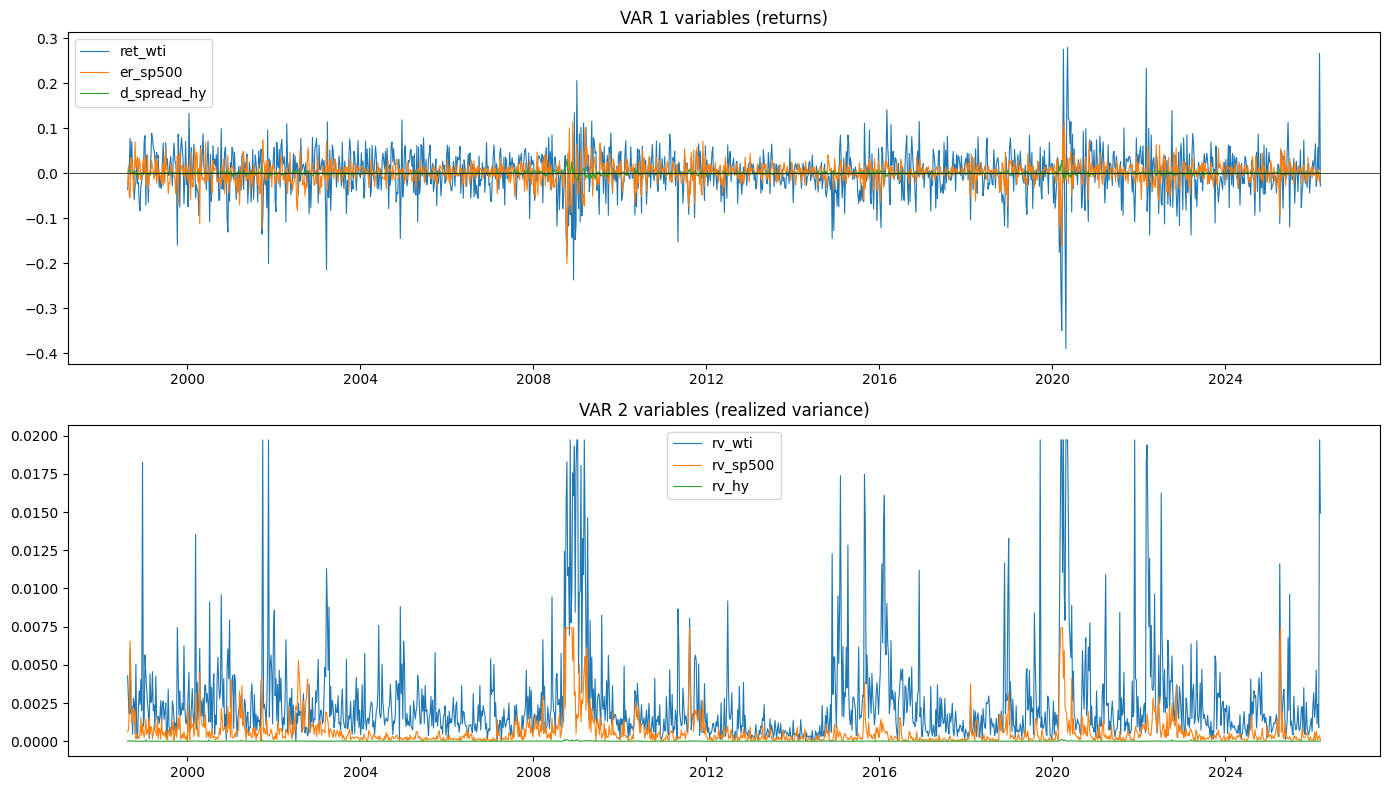

In [11]:
import matplotlib.pyplot as plt

# quick check on the final dataset
print(df_final.describe().round(6).to_string())

# plot to visually confirm the series look reasonable
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for col in ["ret_wti", "er_sp500", "d_spread_hy"]:
    axes[0].plot(df_final.index, df_final[col], label=col, linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("VAR 1 variables (returns)")
axes[0].legend()

for col in ["rv_wti", "rv_sp500", "rv_hy"]:
    axes[1].plot(df_final.index, df_final[col], label=col, linewidth=0.8)
axes[1].set_title("VAR 2 variables (realized variance)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
df_final.to_csv(Path("../data/processed/weekly_cleaned_data.csv"))
print("Exported: ../data/processed/weekly_cleaned_data.csv")

Exported: ../data/processed/weekly_cleaned_data.csv


## 6. Preliminary Statistical Analysis

In [13]:
from scipy import stats

daily_returns  = pd.concat([daily_ret_wti, daily_ret_sp500, daily_d_spread], axis=1).dropna()
weekly_returns = pd.concat([ret_wti, er_sp500, d_spread_hy], axis=1).dropna()

def moment_table(df):
    return pd.DataFrame({
        "mean":            df.mean(),
        "std":             df.std(),
        "skewness":        df.skew(),
        "kurtosis":        df.kurtosis() + 3,
        "excess_kurtosis": df.kurtosis(),
    })

def jb_pvalues(ret):
    return pd.Series({c: stats.jarque_bera(ret[c].dropna().values).pvalue for c in ret.columns})

mom_daily  = moment_table(daily_returns)
mom_weekly = moment_table(weekly_returns).add_prefix("W_")

compare_moments = pd.concat([
    mom_daily[["skewness", "kurtosis", "excess_kurtosis"]].reset_index(drop=True),
    mom_weekly[["W_skewness", "W_kurtosis", "W_excess_kurtosis"]].reset_index(drop=True)
], axis=1)
compare_moments.index = ["ret_wti", "er_sp500", "d_spread_hy"]

display(compare_moments)

jb_daily  = jb_pvalues(daily_returns).rename("JB_p_daily")
jb_weekly = jb_pvalues(weekly_returns).rename("JB_p_weekly")

compare_jb = pd.concat([jb_daily.reset_index(drop=True), jb_weekly.reset_index(drop=True)], axis=1).round(4)
compare_jb.index = ["ret_wti", "er_sp500", "d_spread_hy"]

display(compare_jb)

,skewness,kurtosis,excess_kurtosis,W_skewness,W_kurtosis,W_excess_kurtosis
ret_wti,-1.911451,50.736005,47.736005,-0.602216,9.370869,6.370869
er_sp500,-0.348547,13.603476,10.603476,-0.820673,9.637627,6.637627
d_spread_hy,0.540489,97.640223,94.640223,1.956947,23.881764,20.881764


,JB_p_daily,JB_p_weekly
ret_wti,0.0,0.0
er_sp500,0.0,0.0
d_spread_hy,0.0,0.0


Normality is rejected at both frequencies for all three variables. However, excess kurtosis drops significantly when moving from daily to weekly — most notably for WTI (47.7 → 6.4) — confirming the aggregational normality effect and empirically justifying our choice of weekly frequency.

In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

lags_to_test = [4, 8, 12]  # 1, 2 and 3 months

# Ljung-Box on weekly returns (EMH)
lb_ret = {}
for col in weekly_returns.columns:
    test = acorr_ljungbox(weekly_returns[col].dropna(), lags=lags_to_test, return_df=True)
    lb_ret[col] = test[["lb_stat", "lb_pvalue"]]

display(pd.concat(lb_ret, axis=0).round(4))

# Ljung-Box on realized variance (volatility clustering)
weekly_variances = pd.concat([rv_wti, rv_sp500, rv_hy], axis=1).dropna()

lb_var = {}
for col in weekly_variances.columns:
    test = acorr_ljungbox(weekly_variances[col].dropna(), lags=lags_to_test, return_df=True)
    lb_var[col] = test[["lb_stat", "lb_pvalue"]]

display(pd.concat(lb_var, axis=0).round(4))

lb_stat  lb_pvalue
ret_wti     4     6.4865     0.1656
            8    18.4865     0.0179
            12   24.0645     0.0199
er_sp500    4    18.0847     0.0012
            8    24.6214     0.0018
            12   29.3075     0.0035
d_spread_hy 4   156.8405     0.0000
            8   167.8667     0.0000
            12  175.8268     0.0000

lb_stat  lb_pvalue
rv_wti   4   1165.8994        0.0
         8   1761.5447        0.0
         12  2010.8053        0.0
rv_sp500 4   2092.4375        0.0
         8   2844.4460        0.0
         12  3205.9712        0.0
rv_hy    4    766.2628        0.0
         8   1004.9867        0.0
         12  1222.4130        0.0

The p-values look a little bit weird to us, we will use a plot to nuance these :

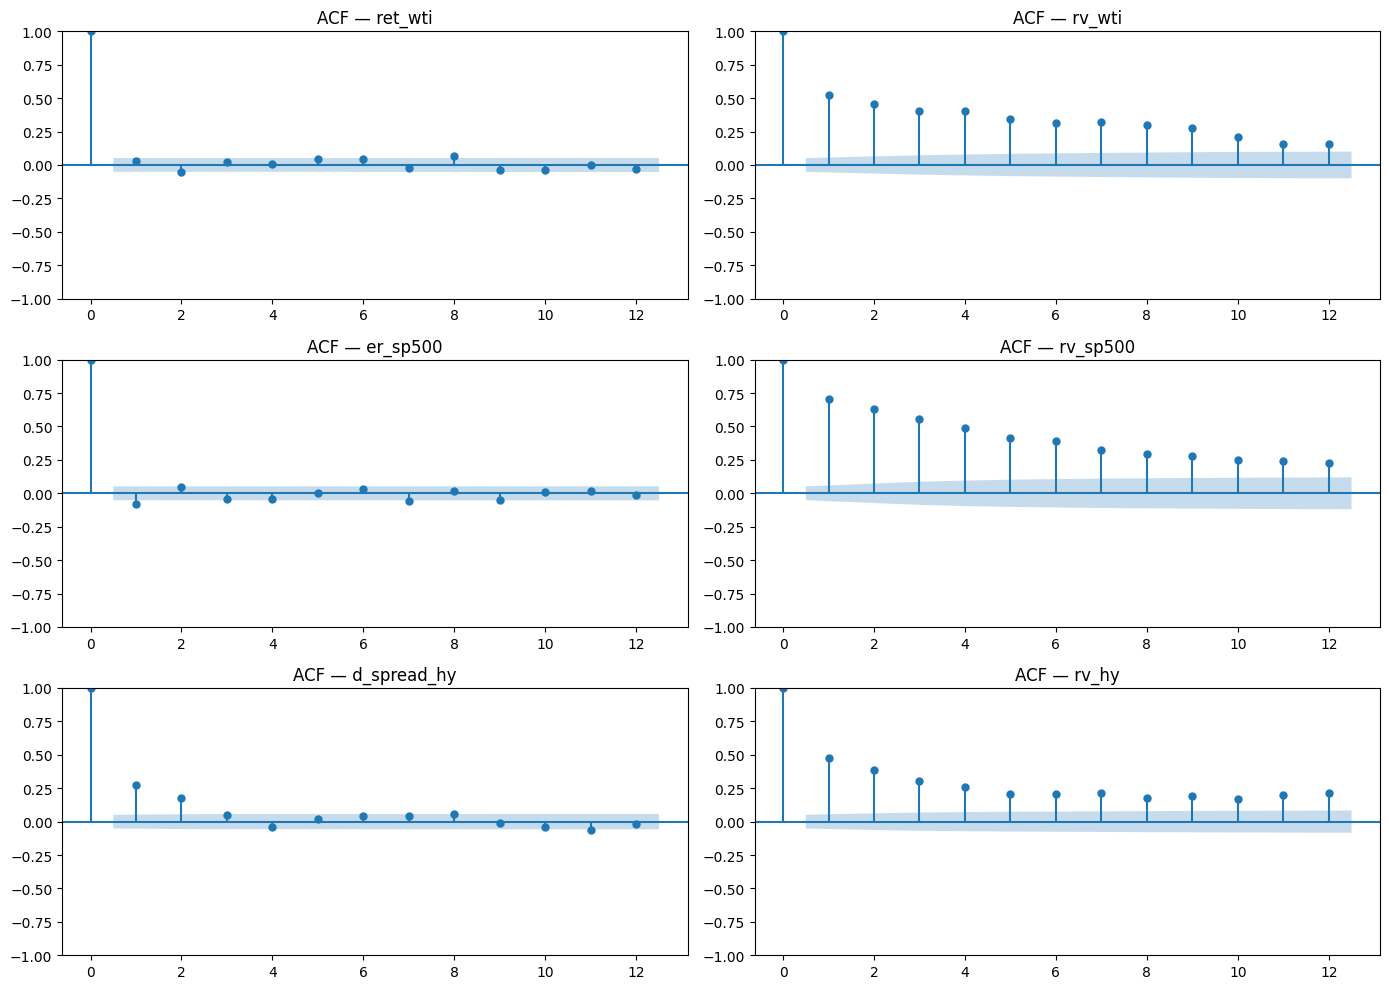

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Returns
plot_acf(ret_wti.dropna(), lags=12, ax=axes[0,0], title="ACF — ret_wti")
plot_acf(er_sp500.dropna(), lags=12, ax=axes[1,0], title="ACF — er_sp500")
plot_acf(d_spread_hy.dropna(), lags=12, ax=axes[2,0], title="ACF — d_spread_hy")

# Realized Variances
plot_acf(rv_wti.dropna(), lags=12, ax=axes[0,1], title="ACF — rv_wti")
plot_acf(rv_sp500.dropna(), lags=12, ax=axes[1,1], title="ACF — rv_sp500")
plot_acf(rv_hy.dropna(), lags=12, ax=axes[2,1], title="ACF — rv_hy")

plt.tight_layout()
plt.show()

On the plots we see the opposite and more logical results, we look with AIs (ChatGPT, Gemini) and internet researches to identify what was wrong with Ljung-Box tests and what we could find is that : "The Ljung-Box test rejected H0 for some return series, but this was a large sample artifact — with T=1440 observations the test is powerful enough to detect autocorrelations so tiny that they are economically meaningless."

So to resume, the plots confirm our expectations. Return series show no meaningful autocorrelation at any lag, supporting the EMH. Realized variances show strong and persistent autocorrelation across all 12 lags, confirming volatility clustering. These two results empirically justify our double VAR approach.

Interesting fact here that we should nuance : HY seems to have autocorrelation to 1 or 2 lag, that might seem to contradict our VAR 2 model hypothesis : if HY is slow to incorporate external information, how can it lead equity markets in risk transmission ? but these are 2 different phenomena, HY are much less liquid reacting slowly to external shocks,  while it may still act as an early warning signal for equity stress through its own persistent volatility dynamics. This is precisely what VAR 2 will test.

In [16]:
# df_final (weekly cleaned data) is passed as df to the models section
df = df_final

---
# VAR Models

In [17]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels as sm

# Time-series econometrics
from statsmodels.tsa.api import VAR

## Testing for Stationarity

In [18]:
variables = df.columns.tolist()
for i in variables:
    result = sm.tsa.stattools.adfuller(df[i])
    print(f"{i:<12}: ADF = {result[0]:8.4f}, nb of lags used {result[2]:>2}, p-value = {result[1]:.6f}")

ret_wti     : ADF = -11.8303, nb of lags used  8, p-value = 0.000000
er_sp500    : ADF = -20.5501, nb of lags used  3, p-value = 0.000000
d_spread_hy : ADF =  -7.9360, nb of lags used 22, p-value = 0.000000
rv_wti      : ADF =  -7.4003, nb of lags used 10, p-value = 0.000000
rv_sp500    : ADF =  -8.5132, nb of lags used  6, p-value = 0.000000
rv_hy       : ADF =  -6.3951, nb of lags used 11, p-value = 0.000000


## Number of lags selection

In [19]:
# VAR 1 lag selection (returns)
var1_data = df[["ret_wti", "d_spread_hy", "er_sp500"]]
model1 = VAR(var1_data)
results1 = model1.select_order(maxlags=20)
print(results1.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -25.49      -25.48   8.527e-12      -25.48
1       -25.64     -25.59*   7.330e-12      -25.62
2       -25.66      -25.58   7.198e-12     -25.63*
3       -25.66      -25.55   7.197e-12      -25.62
4       -25.66      -25.52   7.149e-12      -25.61
5       -25.67      -25.49   7.103e-12      -25.60
6       -25.67      -25.46   7.108e-12      -25.59
7       -25.68      -25.43   7.064e-12      -25.58
8       -25.68      -25.40   7.032e-12      -25.58
9       -25.68      -25.37   7.030e-12      -25.56
10      -25.68      -25.33   7.058e-12      -25.55
11     -25.68*      -25.30  7.020e-12*      -25.54
12      -25.68      -25.27   7.062e-12      -25.52
13      -25.67      -25.23   7.073e-12      -25.51
14      -25.67      -25.20   7.086e-12      -25.49
15      -25.67      -25.16   7.134e-12      -25.48
16      -25.66      -25.11   7.

c:\Users\larao\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


interpretation de des resultats de la selection 2

In [20]:
# VAR 2 lag selection (realized variances)
var2_data = df[["rv_wti", "rv_hy", "rv_sp500"]]
model2 = VAR(var2_data)
results2 = model2.select_order(maxlags=20)
print(results2.summary())

c:\Users\larao\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -48.79      -48.78   6.437e-22      -48.79
1       -49.78      -49.74   2.404e-22      -49.76
2       -49.89     -49.81*   2.152e-22      -49.86
3       -49.91      -49.79   2.120e-22      -49.86
4       -49.92      -49.78   2.085e-22     -49.87*
5       -49.92      -49.74   2.088e-22      -49.85
6       -49.92      -49.71   2.085e-22      -49.84
7       -49.93      -49.68   2.072e-22      -49.84
8       -49.93      -49.65   2.075e-22      -49.82
9       -49.92      -49.61   2.082e-22      -49.81
10      -49.93      -49.58   2.077e-22      -49.80
11      -49.93      -49.55   2.075e-22      -49.79
12      -49.93      -49.52   2.065e-22      -49.78
13     -49.93*      -49.49  2.060e-22*      -49.77
14      -49.93      -49.45   2.070e-22      -49.75
15      -49.93      -49.42   2.071e-22      -49.74
16      -49.92      -49.38   2.

interpretation de des resultats de la selection 2

## Model Var 1

In [21]:
var1_fitted = model1.fit(2)
print(var1_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 28, Mar, 2026
Time:                     13:04:23
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -25.5605
Nobs:                     1438.00    HQIC:                  -25.6087
Log likelihood:           12333.1    FPE:                7.34145e-12
AIC:                     -25.6375    Det(Omega_mle):     7.23527e-12
--------------------------------------------------------------------
Results for equation ret_wti
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.001519         0.001356            1.120           0.263
L1.ret_wti            -0.003263         0.027648           -0.118           0.906
L1.d_spread_hy        -2.661819         0.613157      

Here, we have a lot to interpret and nuance :

- **L1.d_spread_hy → ret_wti (p=0.000, coeff=-2.66)** : the strongest result of VAR 1 : a widening of HY spreads last week predicts a decline in WTI this week. This is an interesting reverse channel : while our research question focuses on oil shocks transmitting to financial markets, this result suggests a feedback loop where credit market stress feeds back into oil prices, consistent with a global risk-off dynamic where deteriorating credit conditions signal weakening economic demand and thus lower oil prices.

- **L2.ret_wti → ret_wti (p=0.004, coeff=-0.081)** : mild mean-reversion of WTI at 2 weeks : a large move tends to partially correct itself.

- **L1.er_sp500 → er_sp500 (p=0.003, coeff=-0.104)** : mild mean-reversion of SP500 at 1 week. This could seem to contradict the EMH, however it is economically negligible after transaction costs and is a well-documented short-term institutional rebalancing effect (mean-reversal phenomena).

- **L1.er_sp500 → d_spread_hy (p=0.008)** : SP500 leads HY in the returns channel :meaning that in terms of price direction, equity markets appear to move before credit markets, which is consistent with the illiquidity and slow price discovery of the HY market discussed earlier.

- **Residual correlation er_sp500 / d_spread_hy = -0.645** : the dominant relationship between SP500 and HY is contemporaneous — when SP500 rises, HY spreads compress instantly within the same week. This fully justifies the Cholesky decomposition to capture this instantaneous channel.

All remaining coefficients are not significant, broadly confirming the EMH past returns of WTI, SP500 and HY carry little predictive power over each other. The dominant dynamics between these markets operate contemporaneously rather than with a lag, which motivates our VAR 2 analysis to uncover the persistent risk transmission channel through realized variances.

In [22]:
var2_fitted = model2.fit(4)
print(var2_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 28, Mar, 2026
Time:                     13:04:23
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -49.7474
Nobs:                     1436.00    HQIC:                  -49.8371
Log likelihood:           29747.6    FPE:                2.15185e-22
AIC:                     -49.8905    Det(Omega_mle):     2.09445e-22
--------------------------------------------------------------------
Results for equation rv_wti
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.000610         0.000097            6.298           0.000
L1.rv_wti           0.270146         0.027358            9.875           0.000
L1.rv_hy           36.369729         7.895391            4.606     

## Granger Causality Tests

In [23]:
def granger_table(fitted, pairs):
    rows = []
    for causing, caused in pairs:
        res = fitted.test_causality(caused=caused, causing=causing)
        rows.append({
            "Causing variable": causing,
            "Caused variable": caused,
            "Test statistic": round(res.test_statistic, 4),
            "p-value": round(res.pvalue, 4),
            "Significant at 5%": "Yes" if res.pvalue < 0.05 else "No",
        })
    return pd.DataFrame(rows)

pairs_var1 = [
    ("ret_wti", "er_sp500"),
    ("ret_wti", "d_spread_hy"),
    ("er_sp500", "ret_wti"),
    ("er_sp500", "d_spread_hy"),
    ("d_spread_hy", "ret_wti"),
    ("d_spread_hy", "er_sp500"),
]

pairs_var2 = [
    ("rv_wti", "rv_sp500"),
    ("rv_wti", "rv_hy"),
    ("rv_sp500", "rv_wti"),
    ("rv_sp500", "rv_hy"),
    ("rv_hy", "rv_wti"),
    ("rv_hy", "rv_sp500"),
]

print("Granger Causality: VAR 1 (returns)")
display(granger_table(var1_fitted, pairs_var1))

print("\nGranger Causality: VAR 2 (realized variances)")
display(granger_table(var2_fitted, pairs_var2))

Granger Causality: VAR 1 (returns)


,Causing variable,Caused variable,Test statistic,p-value,Significant at 5%
0,ret_wti,er_sp500,1.3625,0.2561,No
1,ret_wti,d_spread_hy,1.7520,0.1735,No
2,er_sp500,ret_wti,1.9653,0.1402,No
3,er_sp500,d_spread_hy,4.1346,0.0161,Yes
4,d_spread_hy,ret_wti,11.5768,0.0000,Yes
5,d_spread_hy,er_sp500,0.9272,0.3957,No



Granger Causality: VAR 2 (realized variances)


,Causing variable,Caused variable,Test statistic,p-value,Significant at 5%
0,rv_wti,rv_sp500,2.2974,0.0567,No
1,rv_wti,rv_hy,7.8036,0.0000,Yes
2,rv_sp500,rv_wti,5.7388,0.0001,Yes
3,rv_sp500,rv_hy,12.0214,0.0000,Yes
4,rv_hy,rv_wti,7.0133,0.0000,Yes
5,rv_hy,rv_sp500,5.4570,0.0002,Yes


**Granger Causality Tests — Interpretation :**

**VAR 1 (returns) :** Only two significant relationships : d_spread_hy → ret_wti 
and er_sp500 → d_spread_hy. The latter likely reflects a difference in adjustment 
speed rather than true causality : both markets react to the same information but 
the liquid equity market adjusts instantly while the illiquid HY market takes an 
additional week, consistent with our ACF findings. All other relationships confirm 
the EMH.

**VAR 2 (realized variances) :** The key result is the indirect transmission chain 
WTI → HY → SP500 : oil volatility Granger-causes HY (p=0.000), HY Granger-causes 
SP500 (p=0.0002), but WTI does not directly cause SP500 (p=0.057). This confirms 
our central hypothesis — oil shocks reach equity markets through the credit channel, 
with HY acting as a mediator and early warning signal.

The Granger causality results reveal a clear transmission structure in the variance 
channel. While all three variables are broadly interconnected, the critical finding 
is that WTI does not directly Granger-cause SP500 (p=0.057) but does cause HY 
(p=0.000), which in turn causes SP500 (p=0.0002). This indirect chain 
WTI → HY → SP500 is the only unidirectional path in the system and is precisely 
consistent with our economic intuition : oil volatility first contaminates credit 
markets, which then act as a transmission belt to equity markets.

This result also informs our Cholesky ordering for the IRF analysis : placing WTI 
first, HY second and SP500 last is not only economically justified but now 
empirically supported by the Granger tests.

However, it is important to note that Granger causality captures relationships 
between past levels of variance — it tells us that elevated HY volatility last week 
predicts elevated SP500 volatility this week, but it does not tell us how the system 
responds to a sudden unexpected shock. This is precisely what the Impulse Response 
Functions will address next : by orthogonalizing the shocks via Cholesky 
decomposition, we can trace the dynamic response of HY and SP500 to a one standard 
deviation shock on WTI volatility, and assess both the magnitude and persistence of 
this transmission.

## Impulse Response Functions

c:\Users\larao\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


VAR 1 — t=0 Impulse vector (from WTI return shock):    [ 0.051284 -0.000842  0.006236]
VAR 2 — t=0 Impulse vector (from WTI variance shock): [2.527e-03 2.000e-06 1.570e-04]


c:\Users\larao\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


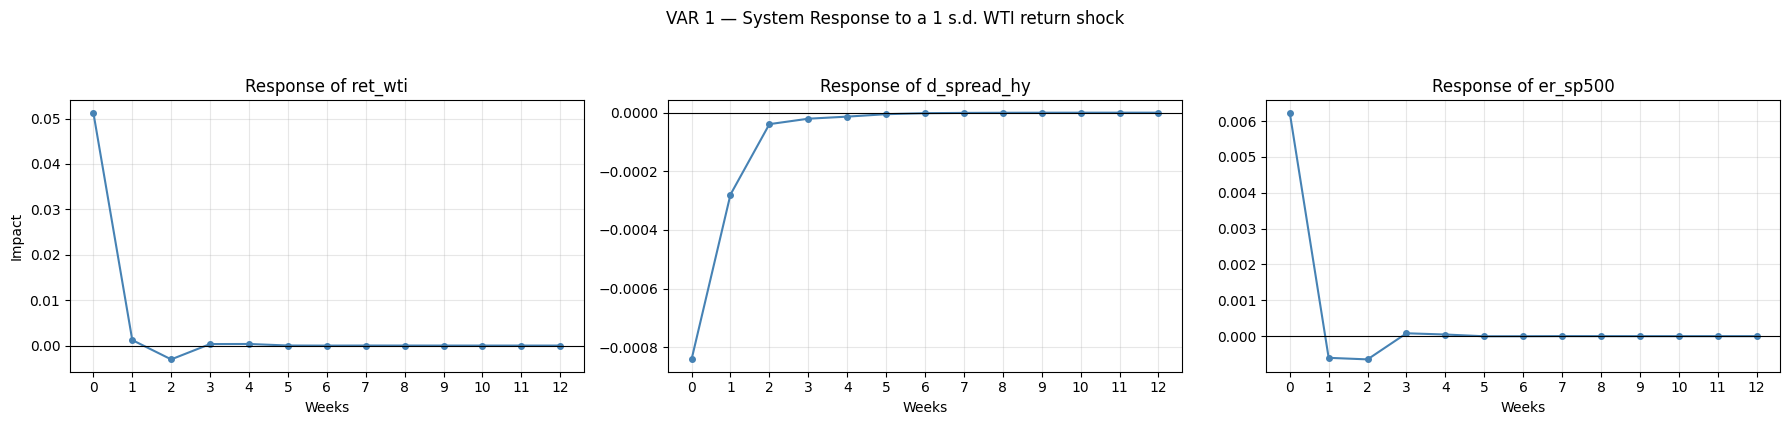

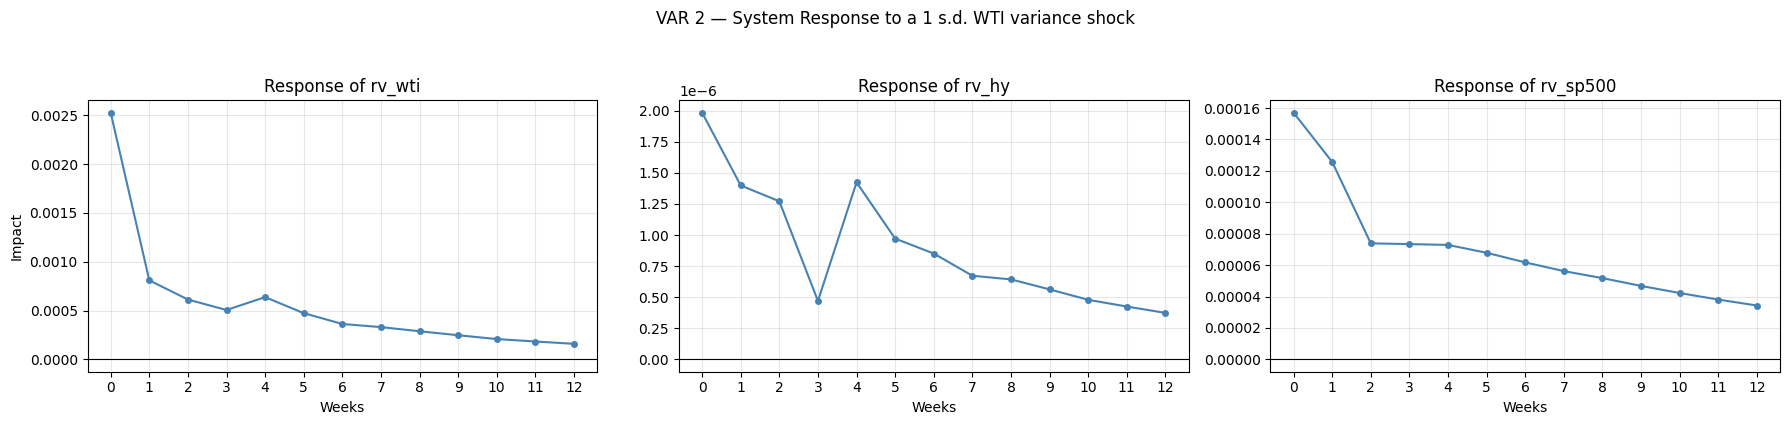

In [24]:
# Cholesky ordering: WTI first, HY second, SP500 last
variables_var1 = ["ret_wti", "d_spread_hy", "er_sp500"]
variables_var2 = ["rv_wti",  "rv_hy",       "rv_sp500"]

irf_var1_fitted = VAR(df[variables_var1]).fit(2)
irf_var2_fitted = VAR(df[variables_var2]).fit(4)

# ============================================================
# Manual Orthogonalized Impulse Response Engine (13 Weeks)
# ============================================================
def compute_irfs_shock(lag_matrices, cholesky_P, shock_vector, n_periods): 
    n_lags = len(lag_matrices) 
    n_vars = lag_matrices.shape[1] 
    
    responses = np.zeros((n_periods + 1, n_vars)) 
    
    # 1. Insert the instantaneous structural shock at Week 0 
    #    (This perfectly equals P @ [1, 0, 0])
    responses[0] = cholesky_P @ shock_vector 
    
    # 2. Echo the shock forward!
    for period in range(1, n_periods + 1): 
        for lag in range(1, min(period, n_lags) + 1): 
            responses[period] += lag_matrices[lag-1] @ responses[period - lag] 
            
    # Returns exactly the 2D matrix (13 weeks x 3 variables)
    return responses


# ------------------------------------------------------------
# Execute Function for Both VARs 
# ------------------------------------------------------------
oil_shock_vector = np.array([1, 0, 0])

# VAR 1 (Returns)
P1 = np.linalg.cholesky(irf_var1_fitted.sigma_u)
manual1_shock_matrix = compute_irfs_shock(irf_var1_fitted.coefs, P1, oil_shock_vector, 12)
print(f"VAR 1 — t=0 Impulse vector (from WTI return shock):    {np.round(manual1_shock_matrix[0], 6)}")

# VAR 2 (Variances)
P2 = np.linalg.cholesky(irf_var2_fitted.sigma_u)
manual2_shock_matrix = compute_irfs_shock(irf_var2_fitted.coefs, P2, oil_shock_vector, 12)
print(f"VAR 2 — t=0 Impulse vector (from WTI variance shock): {np.round(manual2_shock_matrix[0], 6)}")


# ============================================================
# Plotting the Graphs
# ============================================================

# ---- VAR 1 ----
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, (ax, title) in enumerate(zip(axes, variables_var1)):
    # Added markers (marker='o') to easily track weekly points
    ax.plot(manual1_shock_matrix[:, i], color="steelblue", marker='o', markersize=4)
    
    ax.axhline(0, color="black", linewidth=0.8)
    
    # Added gridlines (alpha=0.3) for easier reading
    ax.grid(alpha=0.3)
    
    # Force whole-week increments on the X-axis
    ax.set_xticks(range(13))
    
    ax.set_title(f"Response of {title}")
    ax.set_xlabel("Weeks")
    
    # Put "Impact" label only on the far left graph
    if i == 0:
        ax.set_ylabel("Impact")
fig.suptitle("VAR 1 — System Response to a 1 s.d. WTI return shock", y=1.05)
plt.tight_layout()
plt.show()
# ---- VAR 2 ----
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, (ax, title) in enumerate(zip(axes, variables_var2)):
    ax.plot(manual2_shock_matrix[:, i], color="steelblue", marker='o', markersize=4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(alpha=0.3)
    ax.set_xticks(range(13))
    ax.set_title(f"Response of {title}")
    ax.set_xlabel("Weeks")
    
    if i == 0:
        ax.set_ylabel("Impact")
fig.suptitle("VAR 2 — System Response to a 1 s.d. WTI variance shock", y=1.05)
plt.tight_layout()
plt.show()